In [1]:
import os
import sys

In [2]:
import json

with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [4]:
import tensorflow as tf

In [4]:
print(tf.__version__)

2.19.0


In [7]:
batch_size = 256
features = 40
input_shape = (features,1)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
WINDOW=256
def lstm_vector(ts1, sizes1, ts2, sizes2, voip=False, window=256):
    # 1) determine src/dst order
    if voip or ts1[0] < ts2[0]:
        src_ts, src_sizes, dst_ts, dst_sizes = ts1, sizes1, ts2, sizes2
    else:
        src_ts, src_sizes, dst_ts, dst_sizes = ts2, sizes2, ts1, sizes1

    sizes = []
    j = k = 0
    min_val = min(src_ts[0], dst_ts[0])

    # 2) merge until we have `window` events or exhaust both streams
    while len(sizes) < window:
        if j >= len(src_ts) and k >= len(dst_ts):
            break
        if j >= len(src_ts):
            sizes.append(dst_sizes[k])
            k += 1
        elif k >= len(dst_ts):
            sizes.append(src_sizes[j])
            j += 1
        elif src_ts[j] <= dst_ts[k]:
            sizes.append(src_sizes[j])
            j += 1
        else:
            sizes.append(dst_sizes[k])
            k += 1

    # 3) pad with zeros up to `window`
    if len(sizes) < window:
        sizes.extend([0] * (window - len(sizes)))

    # 4) return as (window, 1)
    return np.array(sizes, dtype=float).reshape(window, 1)

In [9]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"voip":4,"chat":5,"gaming":6,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [10]:
# check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'pseudo_labeled_binary_lstm_acc.weights.h5')
# pipeline.named_steps['model'].load_weights(check_path) 

In [11]:
X_train = []
y_train = []
voip = []
gaming = []
web = []
video = []
social = []
email = []
doc = []
microsoft = []
chat = []
background = []

In [12]:
path2 = os.path.abspath('..')

In [13]:
import os
import csv
import tensorflow as tf

folder_path = path2+"/labeled_train"

In [14]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path:
                    y_train.append(6)
                elif "gaming" in file_path:
                    y_train.append(7)
                elif "web" in file_path:
                    y_train.append(0)
                elif "video" in file_path:
                    y_train.append(1)
                elif "social" in file_path:
                    y_train.append(2)
                elif "email" in file_path:
                    y_train.append(3)
                elif "doc" in file_path:
                    y_train.append(4)
                elif "chat" in file_path:
                    y_train.append(5)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                y_train.append(6)
                X_train.append(v)
            elif "gaming" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                sizes = np.array(sizes, dtype=float)
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    # ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                X_train.append(v)
                y_train.append(7)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [15]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)

In [16]:
import numpy as np

In [17]:
X_dataset = np.array(X_train)

In [18]:
y_dataset = np.array(y_train)

In [19]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(10)]

In [20]:
max_val = max(counts)

In [21]:
max_val

20832

In [22]:
counts

[20832, 2475, 1522, 2791, 336, 170, 1175, 1006, 0, 0]

In [23]:
for i in range(8):
    indices = np.where((y_dataset==i))[0]
    sample = X_dataset[indices]
    value = len(indices)
    print(value)
    if value==max_val:
        continue
    sampled_indices = np.random.choice(len(sample), max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    # augmented = translation(sampled_X)
    # augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,sampled_X))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

20832
2475
1522
2791
336
170
1175
1006


In [24]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(8)]

In [25]:
counts

[20832, 20832, 20832, 20832, 20832, 20832, 20832, 20832]

In [26]:
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)

In [27]:
# y_train = to_categorical(y_train, num_classes=8)
# y_val = to_categorical(y_val, num_classes=8)

In [28]:
num_classes = 8

In [17]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras import layers,models,losses
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import regularizers
from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.models import Sequential
from keras.layers import InputLayer,Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,BatchNormalization,Bidirectional,LayerNormalization
from keras import backend as K
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
path = os.path.abspath('')

def precision(y_true, y_pred):
    # One-hot encode y_true to match y_pred shape
    y_true = K.cast(y_true, 'int32')
    y_true = K.one_hot(y_true, num_classes=K.shape(y_pred)[-1])
    y_true = K.cast(y_true, 'float32')

    # Calculate precision
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def recall(y_true, y_pred):
    # One-hot encode y_true to match y_pred shape
    y_true = K.cast(y_true, 'int32')
    y_true = K.one_hot(y_true, num_classes=K.shape(y_pred)[-1])
    y_true = K.cast(y_true, 'float32')

    # Calculate recall
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec))

# def top_2_categorical_accuracy(y_true, y_pred):
#     return top_k_categorical_accuracy(y_true, y_pred, k=2)

# Custom transformer to transpose data

# Set the ratio for the train-test split

def fsnet_encoder(
    input_steps=256,
    vocab_size=1501,
    embedding_dim=128,
    encoder_n_neurons=128,
    decoder_n_neurons=128,
    n_neurons=128,
    n_outputs=10,
    alpha=1.0,
    use_embedding=True
):
    # 1) Input & (optional) embedding
    inputs = layers.Input(shape=(input_steps,), dtype='int32', name='X')
    x = layers.Lambda(lambda t: tf.abs(t), name='abs')(inputs)
    if use_embedding:
        x = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            name='embedding'
        )(x)
    else:
        x = layers.Reshape((input_steps, 1))(tf.cast(inputs, tf.float32))

    # helper: one 2‑layer Bi‑GRU block
    def bi_gru_stack(units, return_sequences, name):
        cells = [layers.GRUCell(units), layers.GRUCell(units)]
        rnn  = layers.RNN(cells, return_sequences=return_sequences)
        return layers.Bidirectional(rnn, merge_mode='concat', name=name)

    # 2) Encoder: two stacked Bi‑GRU blocks
    x = bi_gru_stack(encoder_n_neurons, True,  name='encoder_gru_1')(x)
    encoder_feats = bi_gru_stack(encoder_n_neurons, False, name='encoder_gru_2')(x)

    # 3) Decoder: one stacked Bi‑GRU block, returning full sequence
    dec_input      = layers.RepeatVector(input_steps, name='repeat_vector')(encoder_feats)
    decoder_output = bi_gru_stack(decoder_n_neurons, True,  name='decoder_gru')(dec_input)

    # 4) Reconstruction head → **vocab‑sized** logits per time‑step
    decoder_reconstruction = layers.TimeDistributed(
        layers.Dense(vocab_size, activation=None),
        name='decoder_reconstruction'
    )(decoder_output)

    # 5) Classification head (uses last decoder state)
    fw_last = layers.Lambda(lambda t: t[:, -1, :decoder_n_neurons], name='dec_fw_last')(decoder_output)
    bw_last = layers.Lambda(lambda t: t[:,  0, decoder_n_neurons:], name='dec_bw_last')(decoder_output)
    decoder_last = layers.Concatenate(name='decoder_state')([fw_last, bw_last])
    prod         = layers.Multiply(name='elem_prod')([encoder_feats, decoder_last])
    abs_diff     = layers.Lambda(lambda x: K.abs(x[0] - x[1]), name='abs_diff')(
                       [encoder_feats, decoder_last]
                   )
    joint_emb    = layers.Concatenate(name='joint_embedding')(
                       [encoder_feats, decoder_last, prod, abs_diff]
                   )
    dense1       = layers.Dense(
                       n_neurons, activation='selu',
                       kernel_regularizer=tf.keras.regularizers.l2(0.003),
                       name='dense1'
                   )(joint_emb)
    logits       = layers.Dense(n_outputs, activation='softmax', name='softmax')(dense1)

    return models.Model(
        inputs=inputs,
        outputs=[logits, decoder_reconstruction],
        name='fs_net'
    )
# Create a scikit-learn pipeline
model = fsnet_encoder()
# Compile the model with custom metrics


# Set up callbacks
checkpoint_dir = os.path.abspath('')+"/tensorboard"
log_dir = os.path.abspath('') + "/log"
MODEL_NAME = "checkpoint"
check_path = os.path.join(checkpoint_dir, MODEL_NAME + '256fsnet_loss.weights.h5')
tensorboard = TensorBoard(log_dir='./Graph', histogram_freq=1, write_graph=True,
                          write_images=True)
checkpointer_loss = ModelCheckpoint(filepath=check_path, verbose=1, save_best_only=True,
                                     save_weights_only=True)
checkpointer_acc = ModelCheckpoint(monitor='val_softmax_f1_score', filepath= os.path.join(checkpoint_dir, MODEL_NAME + '256fsnet_acc.weights.h5'), verbose=1,
                                    save_best_only=True, save_weights_only=True,mode='max')
tensorboard.set_model(model)

early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True,mode='max')



In [18]:
model.compile(
    optimizer='adam',
    loss={
        'softmax':               losses.SparseCategoricalCrossentropy(),
        'decoder_reconstruction': losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    loss_weights={
        'softmax':               1.0,
        'decoder_reconstruction': 1.0,         # or your desired α
    },
    metrics={
        'softmax': ['accuracy', f1_score, precision, recall]
    }
)

In [ ]:
model.fit(
    X_train,
    {
        "softmax": y_train,          # classification target
        "decoder_reconstruction": X_train     # reconstruction target (same as input for autoencoder)
    },
    epochs=500,
    batch_size=batch_size,
    validation_data=(
        X_val,
        {
            "softmax": y_val,
            "decoder_reconstruction": X_val
        }
    ),
    callbacks=[early_stopping, tensorboard, checkpointer_loss, checkpointer_acc]
)

Epoch 1/500
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - decoder_reconstruction_loss: 1.9680 - loss: 3.4123 - softmax_accuracy: 0.6085 - softmax_f1_score: nan - softmax_loss: 0.9951 - softmax_precision: 0.7939 - softmax_recall: 0.4759 
Epoch 1: val_loss improved from inf to 1.85512, saving model to /nas/longleaf/home/paulchoi/session_based/tensorboard/checkpoint256fsnet_loss.weights.h5

Epoch 1: val_softmax_f1_score improved from -inf to 0.81272, saving model to /nas/longleaf/home/paulchoi/session_based/tensorboard/checkpoint256fsnet_acc.weights.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 7462s 14s/step - decoder_reconstruction_loss: 1.9672 - loss: 3.4107 - softmax_accuracy: 0.6087 - softmax_f1_score: nan - softmax_loss: 0.9945 - softmax_precision: 0.7940 - softmax_recall: 0.4762 - val_decoder_reconstruction_loss: 1.2410 - val_loss: 1.8551 - val_softmax_accuracy: 0.8141 - val_softmax_f1_score: 0.8127 - val_softmax_loss: 0.4260 - val_softmax_precision: 0.8430 - val_softmax_recall: 0.7846
Epoch 2/500


In [ ]:
# model = pipeline.named_steps['model']
# model.build(input_shape=(None, 50, 2)) 

In [20]:
from tensorflow.keras import Input
check_path = os.path.join(checkpoint_dir, MODEL_NAME + '256fsnet_loss.weights.h5')
input_shape = (50, 2)

# _ = pipeline.named_steps['model']( Input(shape=input_shape) )

# 2) Now that all weights exist, load them
model.load_weights(check_path)

# 3) (Optional) verify
# pipeline.named_steps['model'].summary()

In [21]:
X_test = []
y_test = []

In [22]:
import csv
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path:
                    y_train.append(6)
                elif "gaming" in file_path:
                    y_train.append(7)
                elif "web" in file_path:
                    y_train.append(0)
                elif "video" in file_path:
                    y_train.append(1)
                elif "social" in file_path:
                    y_train.append(2)
                elif "email" in file_path:
                    y_train.append(3)
                elif "doc" in file_path:
                    y_train.append(4)
                elif "chat" in file_path:
                    y_train.append(5)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                if key[0] in client_ip:
                    sizes = value[1][:256]
                else:
                    sizes = -value[1][:256]
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                y_train.append(6)
                X_train.append(v)
            elif "gaming" in file_path:
                ts = value[0][:256]
                sizes = value[1][:256]
                sizes = np.array(sizes, dtype=float)
                if len(sizes)<256:
                    pad = 256 - len(sizes)
                    # ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = sizes.reshape(-1, 1)
                X_train.append(v)
                y_train.append(7)
            
            
    return X_train, y_train

In [23]:
folder_path = os.path.abspath('..')+"/labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [24]:
X_test = np.array(X_test)

In [25]:
y_test=np.array(y_test)
y_test.shape

(11264,)

In [26]:
# unpack the two outputs
softmax_probs, reconstructions = model.predict(X_test)

# now softmax_probs is (n_samples, num_classes)
y_pred = np.argmax(softmax_probs, axis=1)

352/352 ━━━━━━━━━━━━━━━━━━━━ 153s 427ms/step


2025-07-29 20:07:24.979398: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17313038336 exceeds 10% of free system memory.


In [27]:
y_test=np.array(y_test)
y_test_categorical = y_test

In [28]:
def weighted_accuracy(y_true, y_pred, flow_sizes):
    total_flow_size = sum(flow_sizes)
    weighted_acc = 0
    for i, flow_size in enumerate(flow_sizes):
        if y_true[i] == y_pred[i]:
            prediction = 1
        else:
            prediction = 0
        weighted_acc += flow_size * prediction
    weighted_acc /= total_flow_size
    
    return weighted_acc

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_categorical, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test_categorical, y_pred), 2)
average_f1 = round(f1_score(y_test_categorical, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_categorical, y_pred)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.75
Accuracy: 0.78
Weighted Average F1 Score: 0.81


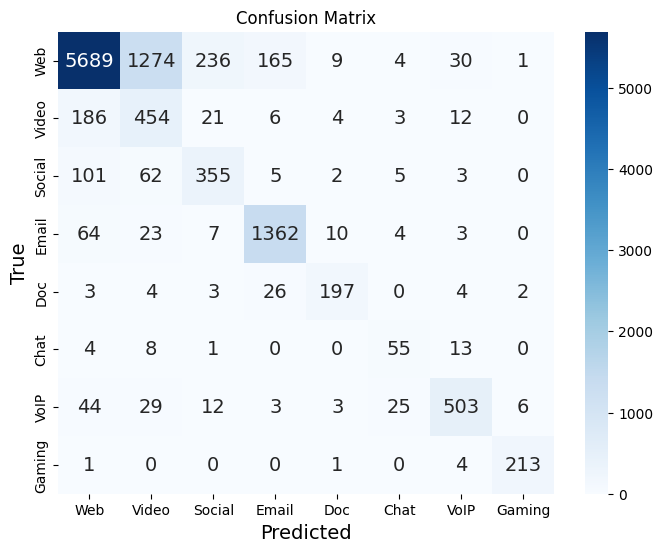

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Chat","VoIP","Gaming"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('fsnet_session.png', dpi=300, bbox_inches='tight')
plt.show()

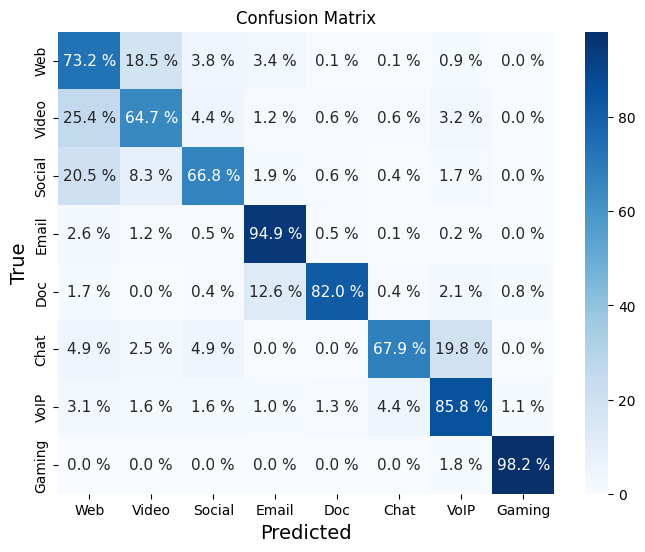

In [29]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Chat","VoIP","Gaming"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# mask for misclassified samples
mask = (y_pred != y_test)

# pick out the probability that the model assigned to its (wrong) prediction
mis_probs = y_pred_prob[mask, y_pred[mask]]

# plot a histogram of those confidences
plt.figure()
plt.hist(mis_probs, bins=20)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Number of misclassified samples')
plt.title('Confidence distribution for misclassified samples')
plt.show()

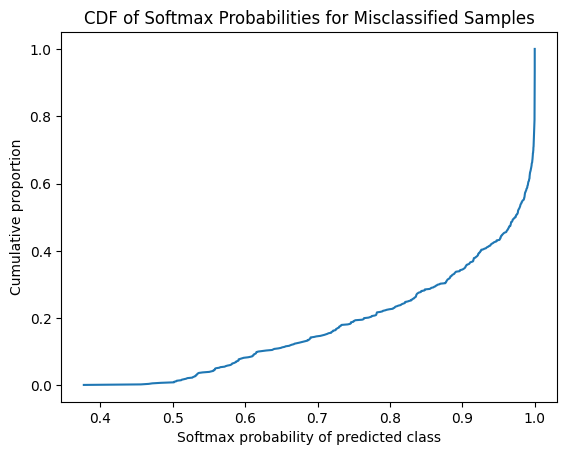

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Select only the misclassified samples
mask = (y_pred != y_test)

# 2) Grab the softmax score assigned to the (wrong) predicted class
mis_probs = y_pred_prob[mask, y_pred[mask]]

# 3) Sort and build the CDF
sorted_probs = np.sort(mis_probs)
cdf = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)

# 4) Plot
plt.figure()
plt.plot(sorted_probs, cdf)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Cumulative proportion')
plt.title('CDF of Softmax Probabilities for Misclassified Samples')
plt.show()

In [59]:
y_pred = np.argmax(y_pred_prob, axis=1)  # shape (N,)

# — Step 1: Compute the “max confidence” per sample — #
# This finds, for each sample i, the highest softmax‐score across all classes.
confidences = np.max(y_pred_prob, axis=1)  # shape: (N,)

# — Step 2: Build a mask for “keep only if max confidence ≥ 0.9” — #
mask_high_conf = confidences >= 0.9  # shape: (N,), dtype=bool

# — Step 3: Filter your arrays by that mask — #
# If you want to keep only rows with confidence ≥ 0.9 in y_pred_prob:
y_pred_prob_filtered = y_pred_prob[mask_high_conf]  # shape: (__ , C)

# If you also want to keep only those predicted‐class indices:
y_pred_filtered = y_pred[mask_high_conf]

In [60]:
y_test_filtered = y_test[mask_high_conf]

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='macro'), 2)
accuracy = round(accuracy_score(y_test_filtered, y_pred_filtered), 2)
average_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_filtered, y_pred_filtered)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.87
Accuracy: 0.96
Weighted Average F1 Score: 0.96


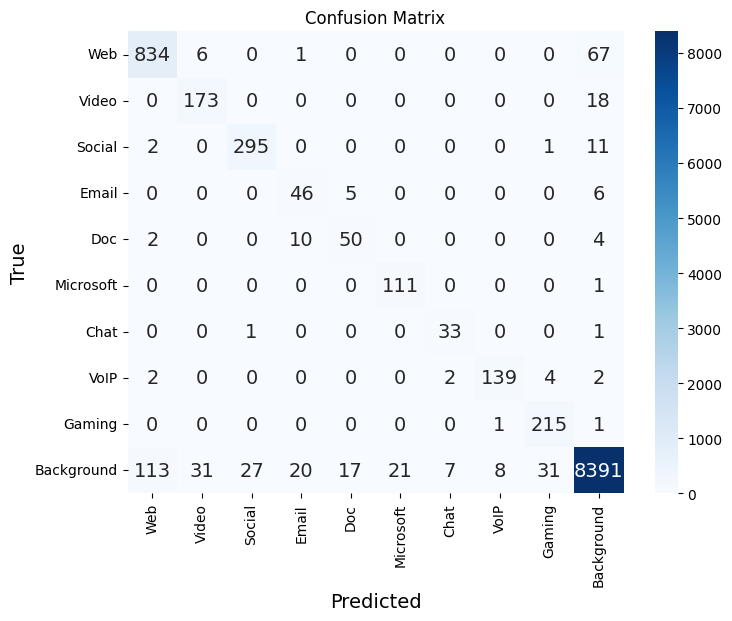

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

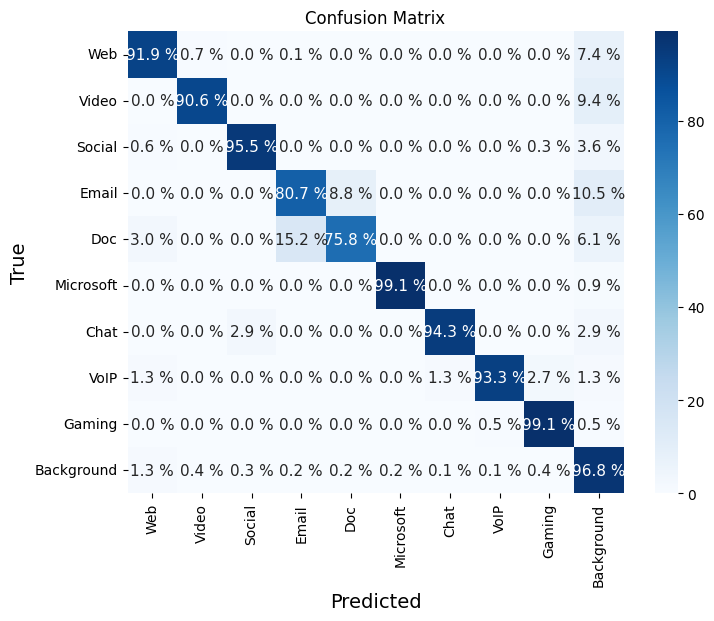

In [63]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()